In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/00001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


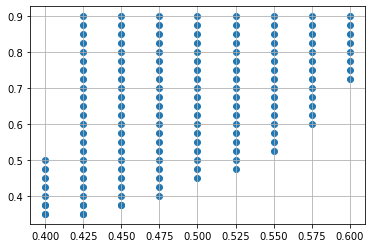

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
-------  21 0.47500000000000014 0.4500000000000002
-------  28 0.5250000000000001 0.4750000000000002
-------  35 0.4250000000000001 0.5250000000000002
-------  42 0.4500000000000001 0.5500000000000003
-------  49 0.47500000000000014 0.5750000000000003
-------  56 0.5000000000000002 0.6000000000000003
-------  63 0.5000000000000002 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  77 0.5000000000000002 0.6750000000000004
-------  84 0.5000000000000002 0.7000000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  98 0.47500000000000014 0.7500000000000004
-------  105 0.4500000000000001 0.7750000000000005
-------  112 0.4250000000000001 0.8000000000000005
-------  119 0.6000000000000003 0.8000000000000005
-------  126 0.5750000000000002 0.8250000000000005
-------  133 0.5500000000000003 0.8500000000

In [12]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140 147]


In [13]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4000000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  0 , total integrated cost =  5538.707762167343
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4000000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4642.275953194359
Gradient descend method:  None
RUN  0 , total integrated cost =  4642.275953194359
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.4500000000000002

In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1217.1004646667843
RUN  2 , total integrated cost =  145.54265181675115
RUN  3 , total integrated cost =  81.18076627177815
RUN  4 , total integrated cost =  57.89040775735947
RUN  5 , total integrated cost =  47.246167878868285
RUN  6 , total integrated cost =  37.964471287131595
RUN  7 , total integrated cost =  30.77362490051481
RUN  8 , total integrated cost =  21.662904899750878
RUN  9 , total integrated cost =  20.603745953979608
RUN  10 , total integrated cost =  19.57246499260319
RUN  11 , total integrated cost =  18.513259872184918
RUN  12 , total integrated cost =  17.412786267335374
RUN  13 , total integrated cost =  16.53979995815088
RUN  14 , total integrated cost =  15.48569270260398
RUN  15 , total integrated c

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  13.364006991987727
Control only changes marginally.
RUN  47 , total integrated cost =  13.364006991165937
Improved over  47  iterations in  11.829033143818378  seconds by  99.77358375709682  percent.
Problem in initial value trasfer:  Vmean_exc -56.627620609847234 -56.62762055099662
weight =  4416.644261814645
set cost params:  1.0 0.0 4416.644261814645
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5873.038102885881
Gradient descend method:  None
RUN  1 , total integrated cost =  5069.690736000906
RUN  2 , total integrated cost =  5068.007241587993
RUN  3 , total integrated cost =  5066.974565799634
RUN  4 , total integrated cost =  5026.069066718552
RUN  5 , total integrated cost =  5024.404141392098
RUN  6 , total integrated cost =  5024.3685680614835
RUN  7 , total integrated cost =  5024.361606003612
RUN  8 , total integrated cost =  5024.359586832437
RUN  9 , total integrated cost =  5024.358710810786
RUN  10 , total int

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  5024.3579154489125
Improved over  22  iterations in  0.50914042070508  seconds by  14.45044579261193  percent.
Problem in initial value trasfer:  Vmean_exc -56.62596343265864 -56.62596386841035
-------  7 0.4000000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  1 , total integrated cost =  666.7946245402984
RUN  2 , total integrated cost =  66.13437158301703
RUN  3 , total integrated cost =  53.531920006140645
RUN  4 , total integrated cost =  42.922410132363126
RUN  5 , total integrated cost =  34.79525947834128
RUN  6 , total integrated cost =  24.863588016731956
RUN  7 , total integrated cost =  24.465655718042537
RUN  8 , total integrated cost =  24.109505915471487
RUN  9 , total integrated cost =  23.70903510835001
RUN  10 , total integrated cost = 

...

RUN  0 , total integrated cost =  15011.243048171957
Gradient descend method:  None
RUN  1 , total integrated cost =  15011.243048171957
Control only changes marginally.
RUN  1 , total integrated cost =  15011.243048171957
Improved over  1  iterations in  0.05205304175615311  seconds by  0.0  percent.
-------  105 0.4500000000000001 0.7750000000000005
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10559.709248318897
Gradient descend method:  None
RUN  1 , total integrated cost =  10559.709248318897
Control only changes marginally.
RUN  1 , total integrated cost =  10559.709248318897
Improved over  1  iterations in  0.046943485736846924  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10559.709248318897
Gradient descend method:  None
RUN  1 , total integrated cost =  10559.709248318897
Control only changes m

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  70.77511868111397
Control only changes marginally.
RUN  53 , total integrated cost =  70.77511868111394
Improved over  53  iterations in  1.1957699824124575  seconds by  99.81838035863947  percent.
Problem in initial value trasfer:  Vmean_exc -56.699987732387115 -56.69998771484537
weight =  5506.012414235303
set cost params:  1.0 0.0 5506.012414235303
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38432.56832113042
Gradient descend method:  None
RUN  1 , total integrated cost =  35603.78937448805
RUN  2 , total integrated cost =  35595.850867601104
RUN  3 , total integrated cost =  35482.07153845144
RUN  4 , total integrated cost =  35436.66117762883
RUN  5 , total integrated cost =  35435.29630376923
RUN  6 , total integrated cost =  35434.469356972724
RUN  7 , total integrated cost =  35430.07838860433
RUN  8 , total integrated cost =  35346.88784442687
RUN  9 , total integrated cost =  35322.40370479639
RUN  10 , total inte

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  35322.117004971
RUN  14 , total integrated cost =  35322.11523013158
RUN  15 , total integrated cost =  35322.11504167619
RUN  16 , total integrated cost =  35322.11501564867
RUN  17 , total integrated cost =  35322.1149608201
RUN  18 , total integrated cost =  35322.11495652143
RUN  19 , total integrated cost =  35322.114956521415
RUN  20 , total integrated cost =  35322.114956521415
Control only changes marginally.
RUN  20 , total integrated cost =  35322.114956521415
Improved over  20  iterations in  0.497318372130394  seconds by  8.093274793969101  percent.
Problem in initial value trasfer:  Vmean_exc -56.699991026964526 -56.69999085679006
-------  126 0.5750000000000002 0.8250000000000005
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33632.4581250047
Gradient descend method:  None
RUN  1 , total integrated cost =  33632.4581250047
Control only changes marginall

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


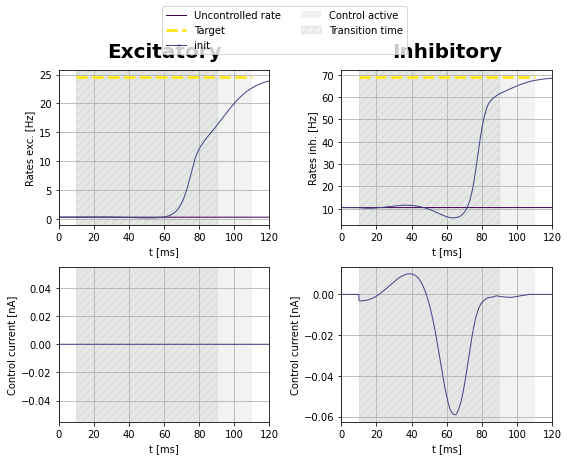

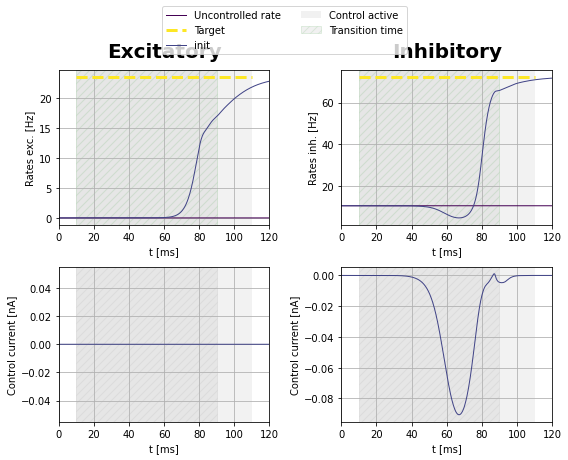

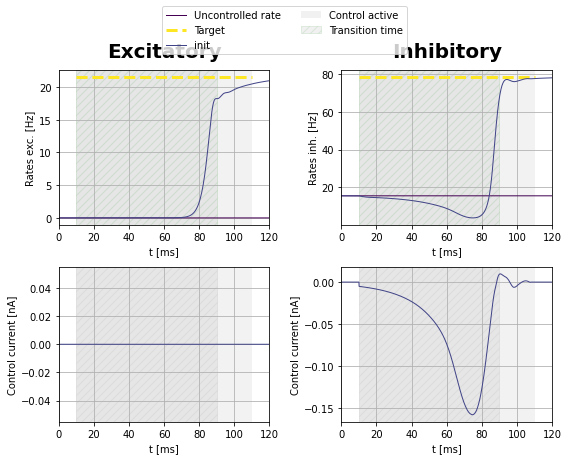

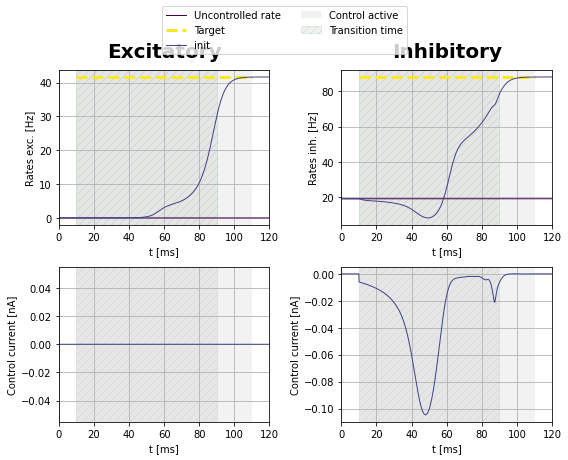

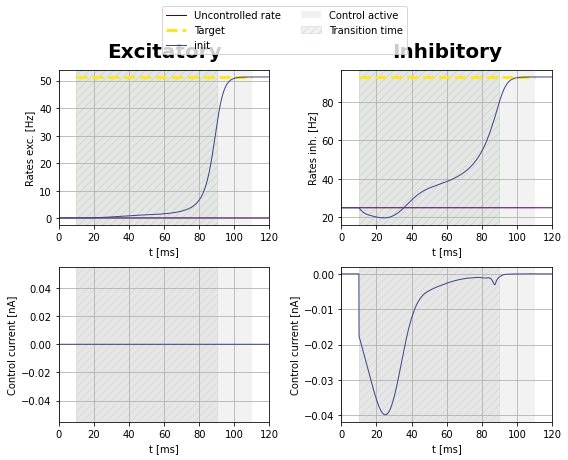

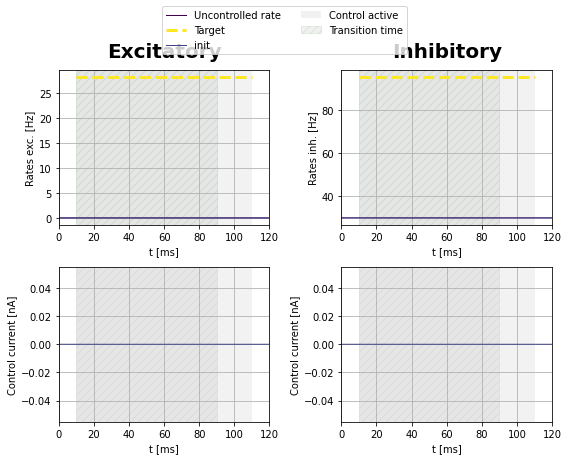

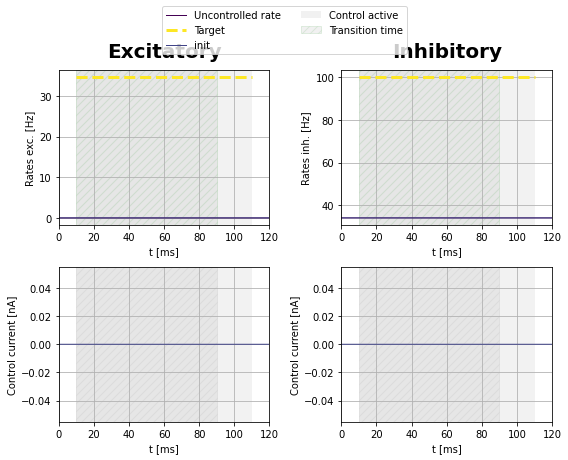

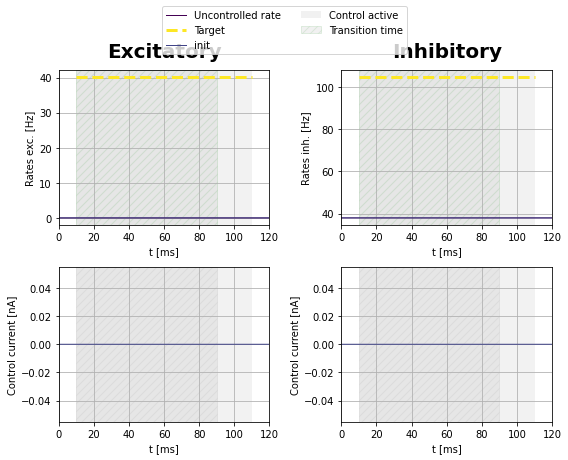

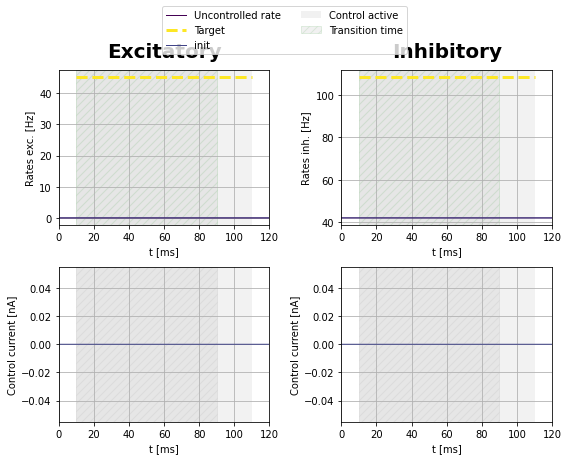

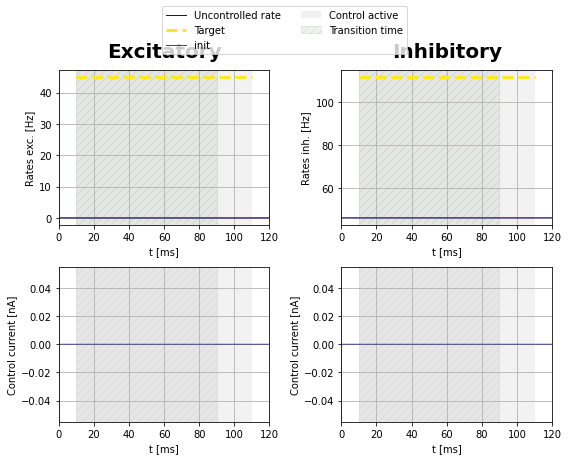

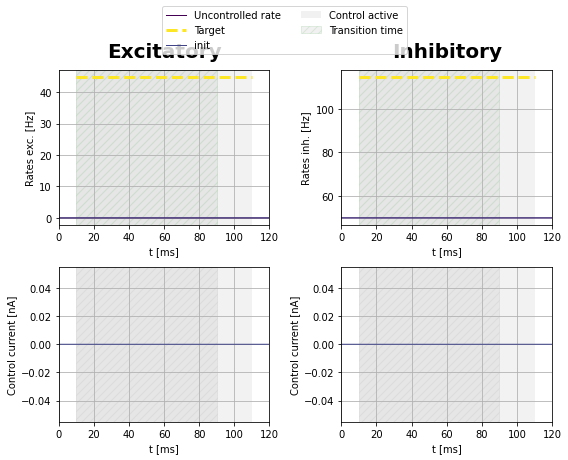

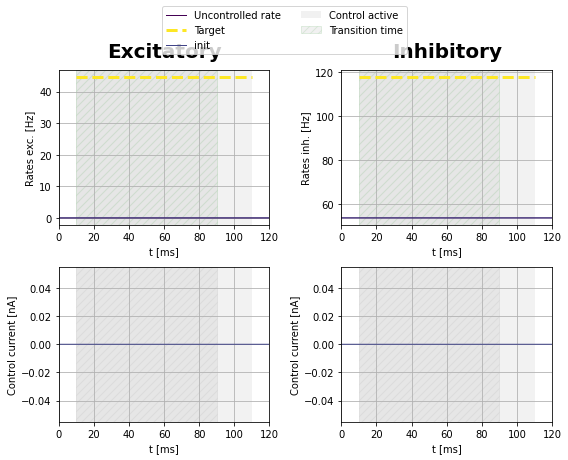

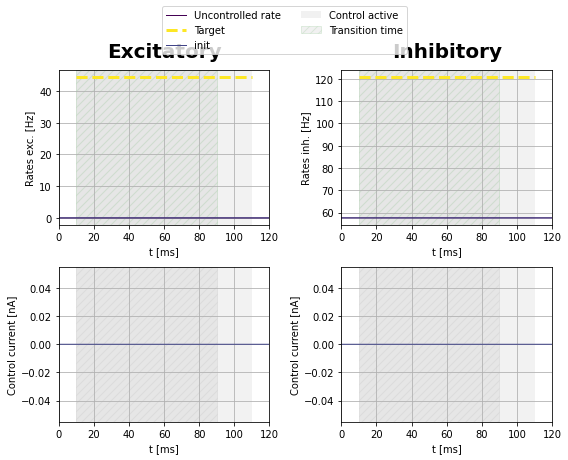

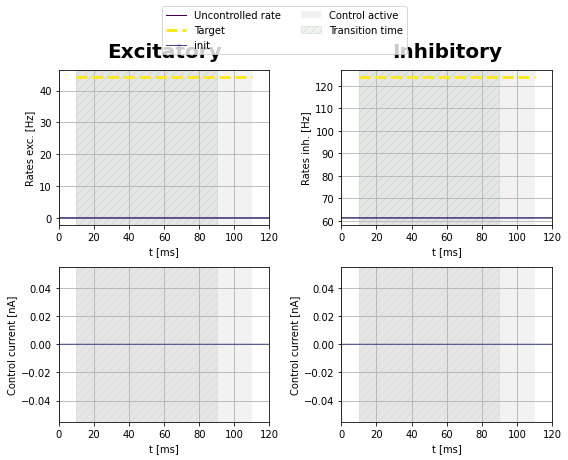

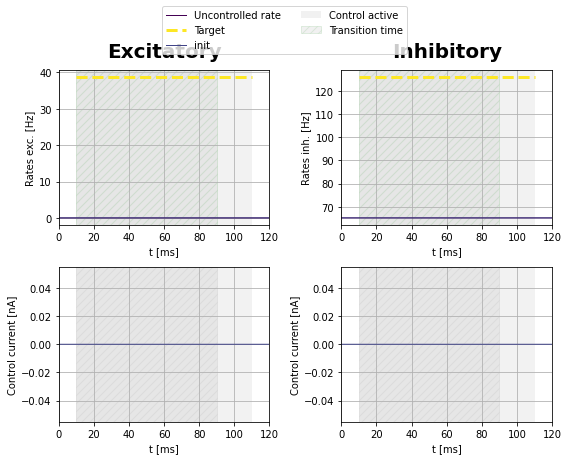

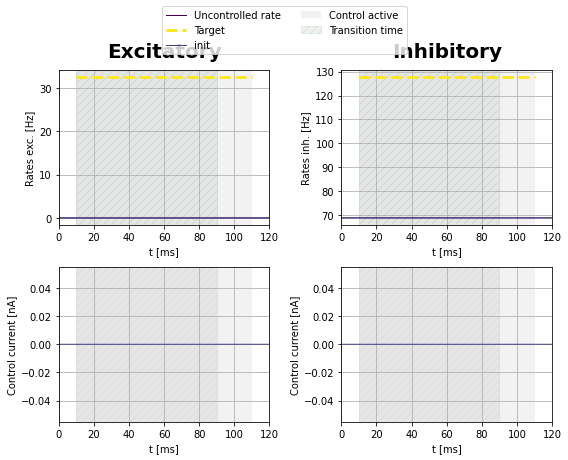

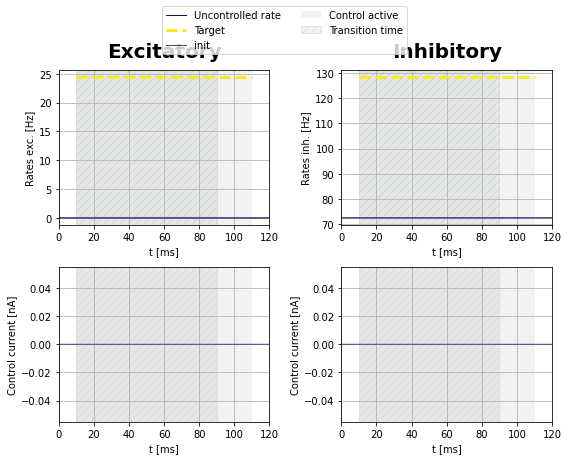

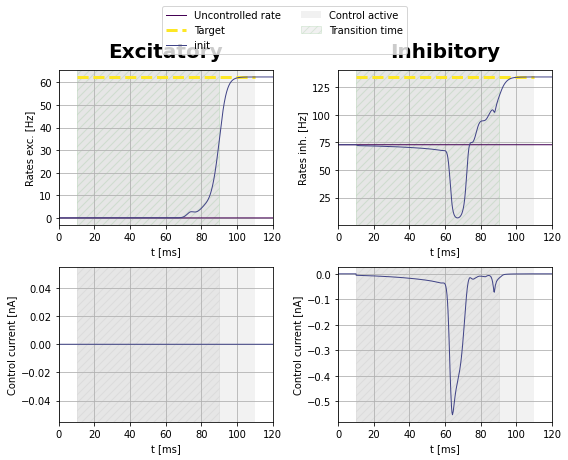

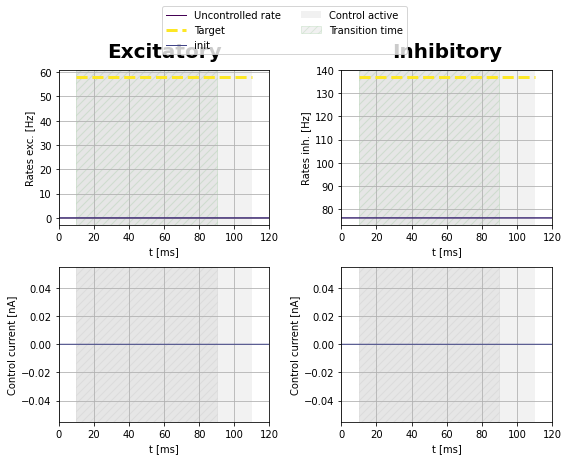

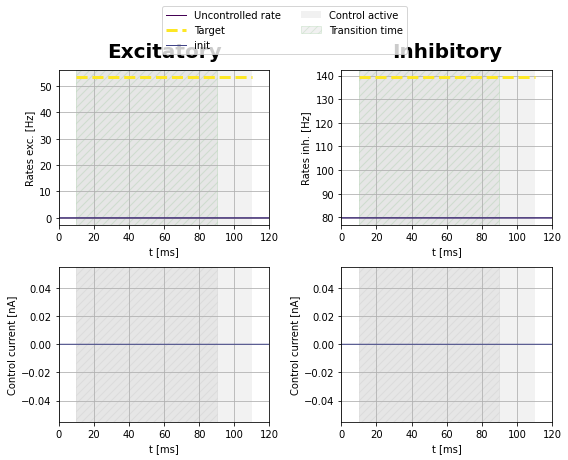

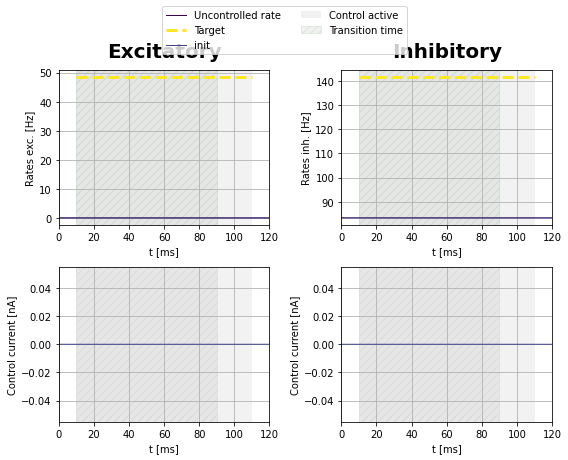

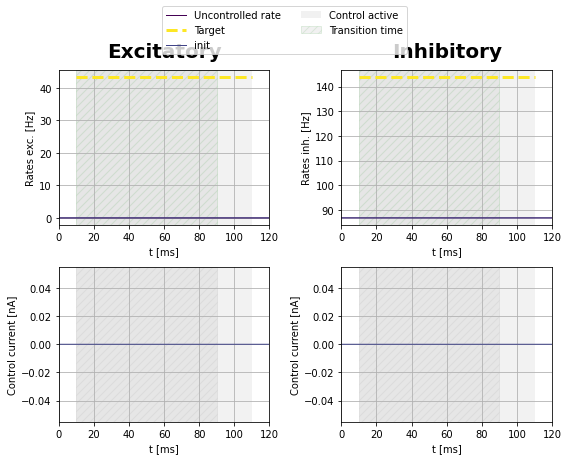

In [15]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
def getclosest(i, found_solution):
    if len(found_solution) == 0:
        print("no solutions found")
        return
    min_dist = np.sqrt((exc[i] - exc[found_solution[0]])**2 + (inh[i] - inh[found_solution[0]])**2)
    min_i = 0
    if i == 0:
        min_dist = np.sqrt((exc[i] - exc[1])**2 + (inh[i] - inh[1])**2)
        min_i = 1
    for i_ in found_solution[1:]:
        if i_ != i and i_ != min_i:
            dist_ = np.sqrt((exc[i] - exc[i_])**2 + (inh[i] - inh[i_])**2)
            if dist_ < min_dist:
                min_dist = dist_
                min_i = i_
    return min_i

found_solution = []
no_solution = []

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('------------------------------------------------------------')
    
    if len(i_range) == len(found_solution):
        break

    # try find solution for all cases
    found_solution = []
    no_solution = []

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
            if i in no_solution:
                no_solution.pop(i)
            continue

        if i not in no_solution:
            print("no solution for ", i)
            no_solution.append(i)

        clostest_ = getclosest(i, found_solution)
        print("closest index ", clostest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        if i != 0:
            control0 = bestControl_init[clostest_][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

------------------------------------------------------------
------------------------------------------------------------
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4000000000000001 0.3750000000000001
found solution for  7
-------  14 0.4000000000000001 0.42500000000000016
found solution for  14
-------  21 0.47500000000000014 0.4500000000000002
found solution for  21
-------  28 0.5250000000000001 0.4750000000000002
found solution for  28
-------  35 0.4250000000000001 0.5250000000000002
no solution for  35
closest index  21
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7997.4831708659
Gradient descend method:  None
RUN  1 , total integrated cost =  7978.733205459808
RUN  2 , total integrated cost =  7978.340664526998
RUN  3 , total integrated cost =  7978.318166813912
RUN  4 , total integrated cost =  7978.3172131405
RUN  5 , total integrated cost =  7978.317208670155
RUN  6 , total inte

ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  7978.317208628129
RUN  9 , total integrated cost =  7978.3172086281265
RUN  10 , total integrated cost =  7978.3172086281265
Control only changes marginally.
RUN  10 , total integrated cost =  7978.3172086281265
Improved over  10  iterations in  0.2557170521467924  seconds by  0.23964992271061192  percent.
Problem in initial value trasfer:  Vmean_exc -76.33803724543546 -76.33804165750965
weight =  9.999999966355755
set cost params:  1.0 0.0 9.999999966355755
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7978.3172086281265
Gradient descend method:  None
RUN  1 , total integrated cost =  2474.2485763783097
RUN  2 , total integrated cost =  1946.4078574779103
RUN  3 , total integrated cost =  1055.80672158253


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  1055.80672158253
Control only changes marginally.
RUN  4 , total integrated cost =  1055.80672158253
Improved over  4  iterations in  0.13795451447367668  seconds by  86.76654870978643  percent.
Problem in initial value trasfer:  Vmean_exc -56.68879747698655 -56.68893031920504
-------  42 0.4500000000000001 0.5500000000000003
no solution for  42
closest index  21
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12036.649500318355
Gradient descend method:  None
RUN  1 , total integrated cost =  12017.89954465343
RUN  2 , total integrated cost =  12017.506995085363
RUN  3 , total integrated cost =  12017.48450610222
RUN  4 , total integrated cost =  12017.483552429014
RUN  5 , total integrated cost =  12017.483543609567
RUN  6 , total integrated cost =  12017.48354355136
RUN  7 , total integrated cost =  12017.483543548995


...

RUN  40 , total integrated cost =  190.15245693038037
Control only changes marginally.
RUN  43 , total integrated cost =  190.15245693038008
Improved over  43  iterations in  0.9569215010851622  seconds by  99.19196296940264  percent.
Problem in initial value trasfer:  Vmean_exc -56.69814006617332 -56.69782384726629
-------  147 0.5000000000000002 0.9000000000000006
no solution for  147
closest index  119
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18862.79587388429
Gradient descend method:  None
RUN  1 , total integrated cost =  18800.29936644675
RUN  2 , total integrated cost =  18799.811086172056
RUN  3 , total integrated cost =  18799.79430153743
RUN  4 , total integrated cost =  18799.793844873282
RUN  5 , total integrated cost =  18799.79383513195
RUN  6 , total integrated cost =  18799.793834791704
RUN  7 , total integrated cost =  18799.79383478734
RUN  8 , total integrated cost =  18799.793834787204
RUN  9 , total inte

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  78 , total integrated cost =  138.4118703740842
Improved over  78  iterations in  1.6902705766260624  seconds by  65.85911567222308  percent.
Problem in initial value trasfer:  Vmean_exc -56.692022878363595 -56.69202193514628
weight =  1358.2501113507979
set cost params:  1.0 0.0 1358.2501113507979
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18611.03895134408
Gradient descend method:  None
RUN  1 , total integrated cost =  18047.165731967292
RUN  2 , total integrated cost =  18044.749756901485
RUN  3 , total integrated cost =  18044.36744285227
RUN  4 , total integrated cost =  18042.96703390522
RUN  5 , total integrated cost =  18029.326315597118
RUN  6 , total integrated cost =  18025.153835710593
RUN  7 , total integrated cost =  18024.974653454225
RUN  8 , total integrated cost =  18024.88460298207
RUN  9 , total integrated cost =  18024.65955738926
RUN  10 , total integrated cost =  18011.58180867617
RUN  11 , total

ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  17994.334543313555
RUN  19 , total integrated cost =  17994.33454331355
RUN  20 , total integrated cost =  17994.33454331355
Control only changes marginally.
RUN  20 , total integrated cost =  17994.33454331355
Improved over  20  iterations in  0.4733661785721779  seconds by  3.3136484730530924  percent.
Problem in initial value trasfer:  Vmean_exc -56.69192900207317 -56.69193093849363
------------------------------------------------------------
------------------------------------------------------------
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4000000000000001 0.3750000000000001
found solution for  7
-------  14 0.4000000000000001 0.42500000000000016
found solution for  14
-------  21 0.47500000000000014 0.4500000000000002
found solution for  21
-------  28 0.5250000000000001 0.4750000000000002
found solution for  28
-------  35 0.4250000000000001 0.5250000000000002
found solution for  35
-------  42 0.4500

In [17]:
factor_iteration = 20
full_converge = False

while full_converge == False:
    
    if all(conv == True for conv in conv_init[::i_stepsize][0]):
        if all(conv == True for conv in conv_init[::i_stepsize][1]):
            full_converge = True
            break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5187.489782399709
set cost params:  1.0 0.0 5187.489782399709
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5855.6162417789765
Gradient descend method:  None
RUN  1 , total integrated cost =  5853.626174270826
RUN  2 , total integrated cost =  5853.571818061239
RUN  3 , total integrated cost =  5853.563660208321
RUN  4 , total integrated cost =  5853.5615104375665
RUN  5 , total integrated cost =  5853.560870870588
RUN  6 , total integrated cost =  5853.560656564933
RUN  7 , total integrated cost =  5853.560557048819
RUN  8 , total integrated cost =  5853.560515661002
RUN  9 , total integrated cost =  5853.5604988135965
RUN  10 , total integrated cost =  5853.560491156488
RUN  11 , total integrated cost =  5853.560488248273
RUN  12 , total integrated cost =  5853.560486909297
RUN  13 , total integrated cost =  5853.560486236649
RUN  14 , total integrated cost =  5853.5604859011055
RUN  1

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  5853.560485563135
Control only changes marginally.
RUN  32 , total integrated cost =  5853.5604855631345
Improved over  32  iterations in  0.7174253799021244  seconds by  0.03510742731353389  percent.
Problem in initial value trasfer:  Vmean_exc -56.62602349904506 -56.62600093381703
-------  7 0.4000000000000001 0.3750000000000001
no convergence
weight =  3143.3484227883846
set cost params:  1.0 0.0 3143.3484227883846
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5524.021853967326
Gradient descend method:  None
RUN  1 , total integrated cost =  5523.714881616299
RUN  2 , total integrated cost =  5523.702473460461
RUN  3 , total integrated cost =  5523.701528125703
RUN  4 , total integrated cost =  5523.701443882364
RUN  5 , total integrated cost =  5523.701435388524
RUN  6 , total integrated cost =  5523.701433546146
RUN  7 , total integrated cost =  5523.701433212963
RUN  8 , total integrated cost =  5523.701433144659
RUN  9

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  5523.701433128301
RUN  16 , total integrated cost =  5523.701433128301
Control only changes marginally.
RUN  16 , total integrated cost =  5523.701433128301
Improved over  16  iterations in  0.38998196087777615  seconds by  0.005800499119942515  percent.
Problem in initial value trasfer:  Vmean_exc -56.625847806144 -56.625831537857444
-------  14 0.4000000000000001 0.42500000000000016
no convergence
weight =  1384.162486203351
set cost params:  1.0 0.0 1384.162486203351
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4638.271004694887
Gradient descend method:  None
RUN  1 , total integrated cost =  4638.267983552863
RUN  2 , total integrated cost =  4638.26754646431
RUN  3 , total integrated cost =  4638.267468331605
RUN  4 , total integrated cost =  4638.267459596137
RUN  5 , total integrated cost =  4638.2674584166425
RUN  6 , total integrated cost =  4638.267458276758
RUN  7 , total integrated cost =  4638.267458256286
RUN  

...

RUN  2 , total integrated cost =  28467.207420865943
Control only changes marginally.
RUN  2 , total integrated cost =  28467.207420865943
Improved over  2  iterations in  0.13286671601235867  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.704014728520185 -56.70401481625494
-------  140 0.5250000000000001 0.8750000000000006
no convergence
weight =  2045.0202036321937
set cost params:  1.0 0.0 2045.0202036321937
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23521.134415961136
Gradient descend method:  None
RUN  1 , total integrated cost =  23521.134415961136
Control only changes marginally.
RUN  1 , total integrated cost =  23521.134415961136
Improved over  1  iterations in  0.07240286655724049  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70070028999082 -56.70069812942823
-------  147 0.5000000000000002 0.9000000000000006
converged for  147
-------  0 0.4000000000000001 0.350000000000

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5536.950635596091
RUN  2 , total integrated cost =  5536.950635596091
Control only changes marginally.
RUN  2 , total integrated cost =  5536.950635596091
Improved over  2  iterations in  0.1331884115934372  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.62585195953013 -56.62583565399172
-------  14 0.4000000000000001 0.42500000000000016
converged for  14
-------  21 0.47500000000000014 0.4500000000000002
converged for  21
-------  28 0.5250000000000001 0.4750000000000002
converged for  28
-------  35 0.4250000000000001 0.5250000000000002
converged for  35
-------  42 0.4500000000000001 0.5500000000000003
converged for  42
-------  49 0.47500000000000014 0.5750000000000003
converged for  49
-------  56 0.5000000000000002 0.6000000000000003
converged for  56
-------  63 0.5000000000000002 0.6250000000000003
converged for  63
-------  70 0.5000000000000002 0.6500000000000004
converged for  70
-------  77 0.5

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28467.207450549242
Control only changes marginally.
RUN  1 , total integrated cost =  28467.207450549242
Improved over  1  iterations in  0.07307872734963894  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.704014728520185 -56.70401481625494
-------  140 0.5250000000000001 0.8750000000000006
converged for  140
-------  147 0.5000000000000002 0.9000000000000006
converged for  147
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4000000000000001 0.3750000000000001
no convergence
weight =  3151.140166970825
set cost params:  1.0 0.0 3151.140166970825
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5536.950636050895
Gradient descend method:  None
RUN  1 , total integrated cost =  5536.950636050895
Control only changes marginally.
RUN  1 , total integrated cost =  5536.950636050895
Improved over  1  iterations in  0.07204514928162098  seconds by  0.0  percent.
Problem in initia

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
factor_iteration = 20
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  319.16442475079856
Gradient descend method:  None
RUN  1 , total integrated cost =  13.46219001281922
RUN  2 , total integrated cost =  13.381872165020408
RUN  3 , total integrated cost =  13.373593531844227
RUN  4 , total integrated cost =  13.35425572089186
RUN  5 , total integrated cost =  13.33911222172979
RUN  6 , total integrated cost =  13.331291196861876
RUN  7 , total integrated cost =  13.327112438638004
RUN  8 , total integrated cost =  13.311939683688585
RUN  9 , total integrated cost =  13.301215418133204
RUN  10 , total integrated cost =  13.29847808955512
RUN  11 , total integrated cost =  13.292482502139103
RUN  12 , total integrated cost =  13.289347796240236
RUN  13 , total integrated cost =  13.271197782151278
RUN  14 , total integrated cost =  13.259935995823144
RUN  15 , total integrated cost =  13.247960078466189
R

ERROR:root:Problem in initial value trasfer


RUN  60 , total integrated cost =  13.117948845259276
Control only changes marginally.
RUN  62 , total integrated cost =  13.11794884525926
Improved over  62  iterations in  3.5621874537318945  seconds by  95.8899088281842  percent.
Problem in initial value trasfer:  Vmean_exc -56.627619644491666 -56.62761962437814
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  130.7049663624899
Gradient descend method:  HS
RUN  1 , total integrated cost =  129.13760996949895
RUN  2 , total integrated cost =  128.1856603405568
RUN  3 , total integrated cost =  128.05518872160377
RUN  4 , total integrated cost =  128.04005455244086
RUN  5 , total integrated cost =  127.99187847956927
RUN  6 , total integrated cost =  127.99187847956921
RUN  7 , total integrated cost =  127.99037817797164
RUN  8 , total integrated cost =  127.10537722579662
RUN  9 , total integrated cost =  126.92332694455247
RUN  10 , total integrated cost =  126.874

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  54 , total integrated cost =  114.94688570793588
Improved over  54  iterations in  4.055818581953645  seconds by  12.056221804802306  percent.
Problem in initial value trasfer:  Vmean_exc -56.627575451842574 -56.627575784214436
weight =  5133.898995206866
set cost params:  1.0 0.0 5133.898995206866
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5816.061744137391
Gradient descend method:  None
RUN  1 , total integrated cost =  5373.033290911196
RUN  2 , total integrated cost =  5365.151930223573
RUN  3 , total integrated cost =  5363.751475757443
RUN  4 , total integrated cost =  5357.038838486859
RUN  5 , total integrated cost =  5351.616202425803
RUN  6 , total integrated cost =  5351.201726319592
RUN  7 , total integrated cost =  5351.042947327661
RUN  8 , total integrated cost =  5351.02832515091
RUN  9 , total integrated cost =  5351.020414389015
RUN  10 , total integrated cost =  5351.017176434636
RUN  11 , total integ

...

RUN  1000 , total integrated cost =  131.12873941145043
RUN  1000 , total integrated cost =  131.12873941145043
Improved over  1000  iterations in  62.4398203715682  seconds by  52.76956040500835  percent.
Problem in initial value trasfer:  Vmean_exc -56.69199732159265 -56.69199763092712
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1310.8952488724485
Gradient descend method:  HS
RUN  1 , total integrated cost =  1309.7423916910811
RUN  2 , total integrated cost =  1305.4840228891005
RUN  3 , total integrated cost =  1304.883512462033
RUN  4 , total integrated cost =  1304.545397182265
RUN  5 , total integrated cost =  1304.4742475387998
RUN  6 , total integrated cost =  1304.3726317101261
RUN  7 , total integrated cost =  1304.2305123675965
RUN  8 , total integrated cost =  1304.2305123675962
RUN  9 , total integrated cost =  1304.143690203535
RUN  10 , total integrated cost =  1302.466220724135
RUN  11 , total in

ERROR:root:Problem in initial value trasfer


RUN  60 , total integrated cost =  1293.4828183832508
Control only changes marginally.
RUN  60 , total integrated cost =  1293.4828183832508
Improved over  60  iterations in  4.3777057733386755  seconds by  1.3282854220560125  percent.
Problem in initial value trasfer:  Vmean_exc -56.69202089499092 -56.69201970773669
weight =  1452.424318251512
set cost params:  1.0 0.0 1452.424318251512
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18771.932519882102
Gradient descend method:  None
RUN  1 , total integrated cost =  18671.858011675708
RUN  2 , total integrated cost =  18620.435712937724
RUN  3 , total integrated cost =  18619.508011392085
RUN  4 , total integrated cost =  18617.445992565023
RUN  5 , total integrated cost =  18606.484849968027
RUN  6 , total integrated cost =  18600.572348677502
RUN  7 , total integrated cost =  18600.556008728465
RUN  8 , total integrated cost =  18600.555699736622
RUN  9 , total integrated cost =  18600.555699373155
RUN  10 , 

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  18600.55569936214
RUN  13 , total integrated cost =  18600.55569936214
Control only changes marginally.
RUN  13 , total integrated cost =  18600.55569936214
Improved over  13  iterations in  1.1378467213362455  seconds by  0.9129418100051794  percent.
Problem in initial value trasfer:  Vmean_exc -56.69200458599397 -56.69200465697246


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


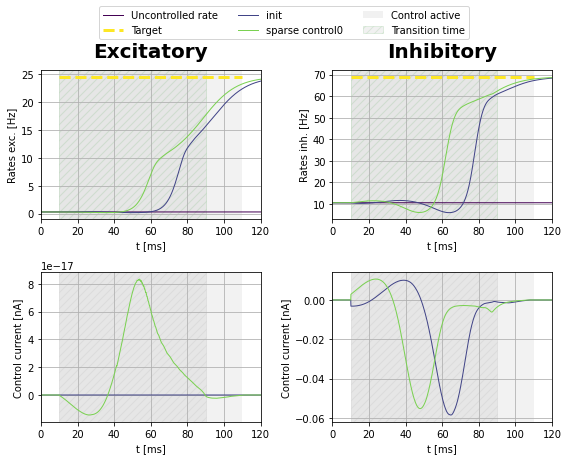

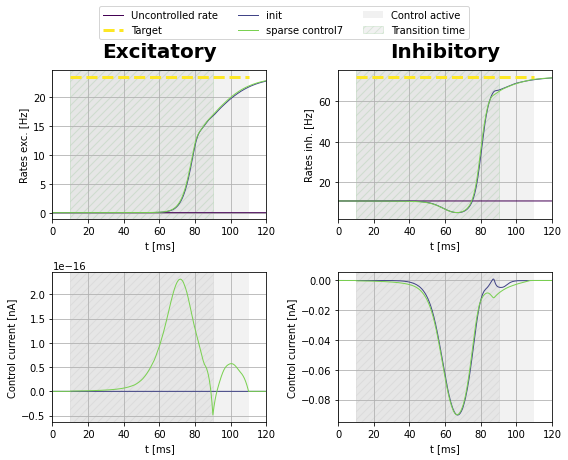

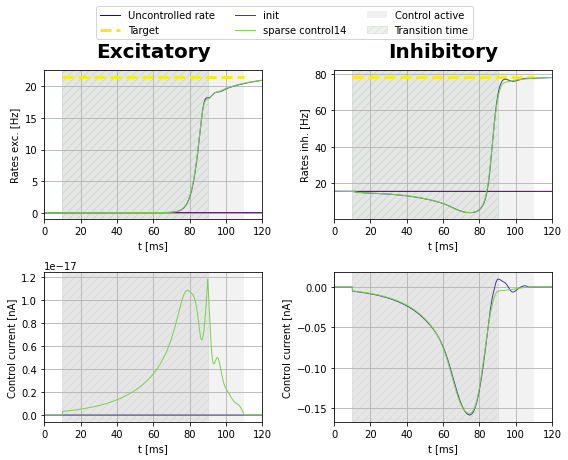

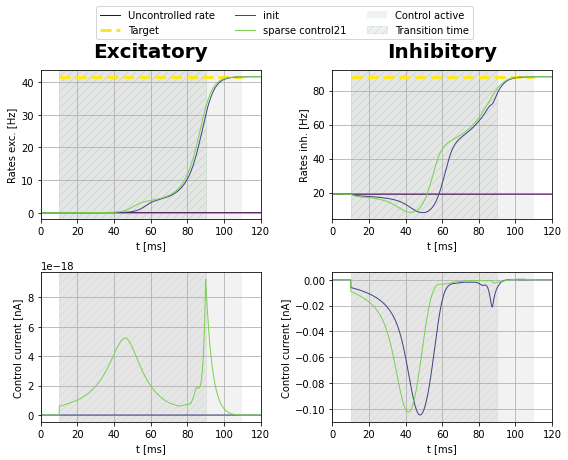

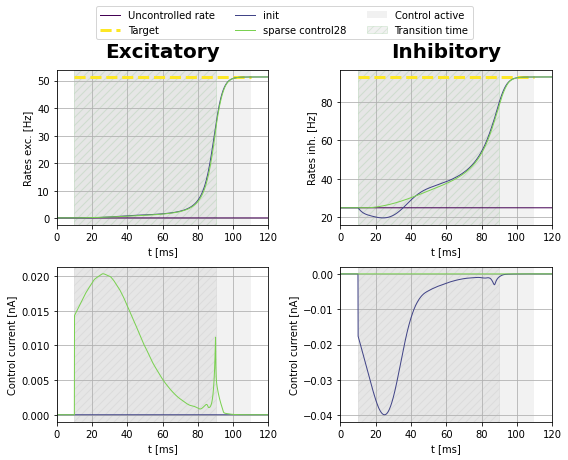

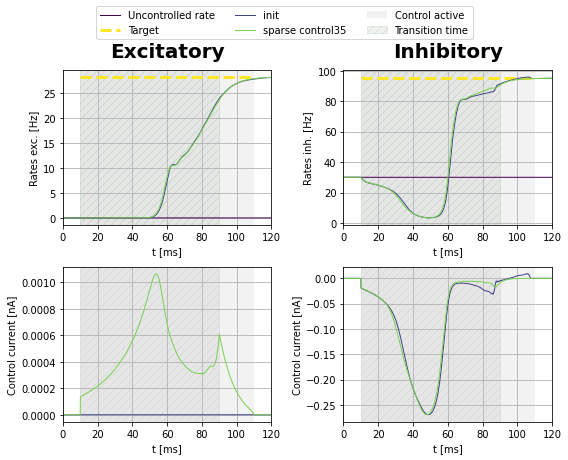

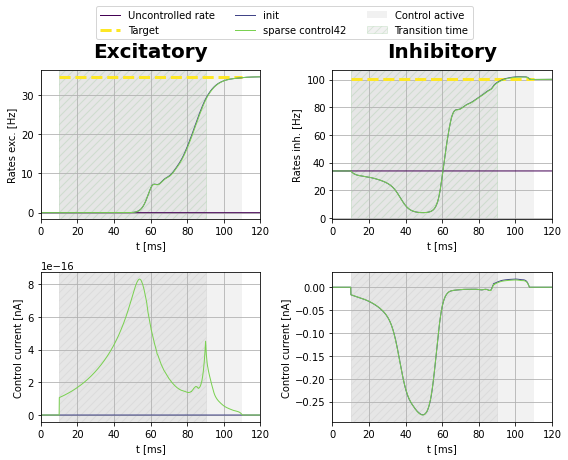

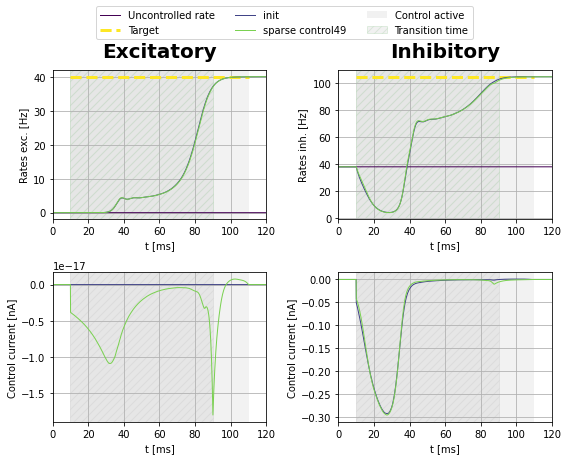

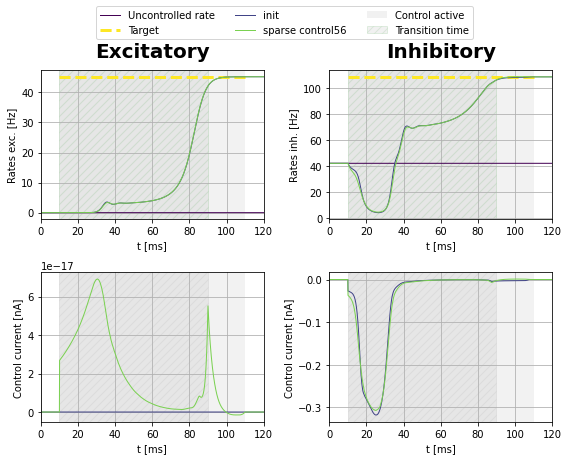

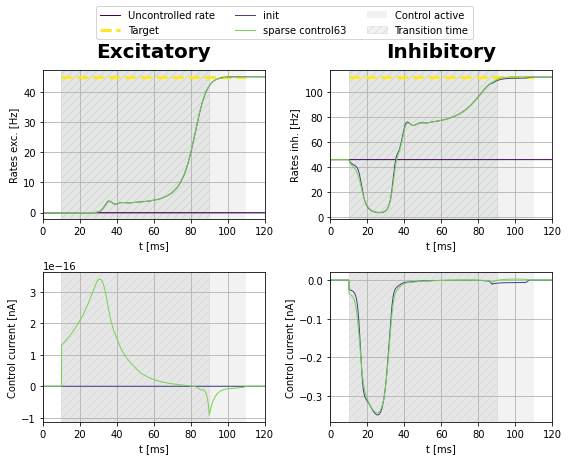

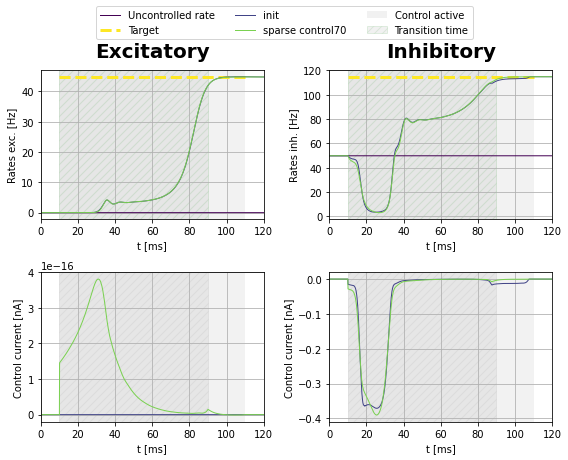

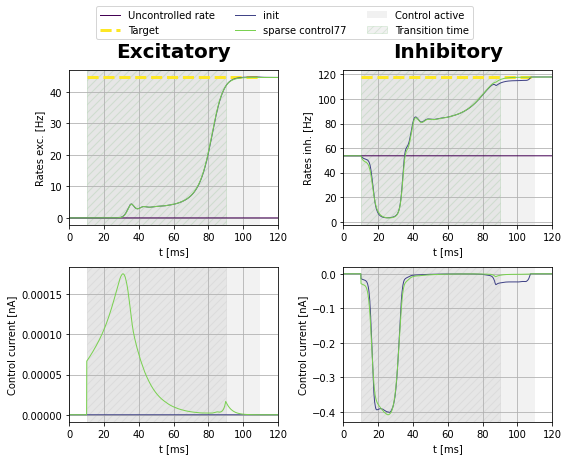

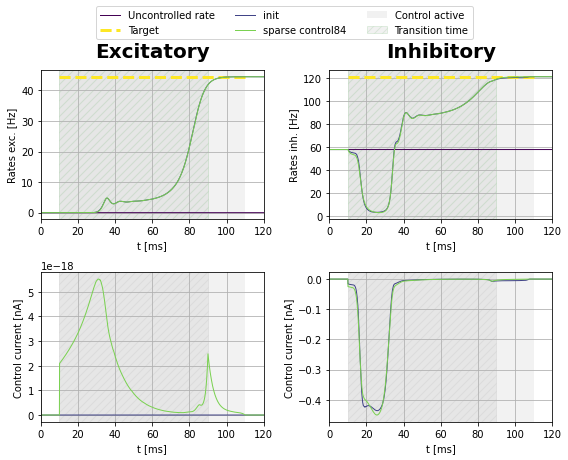

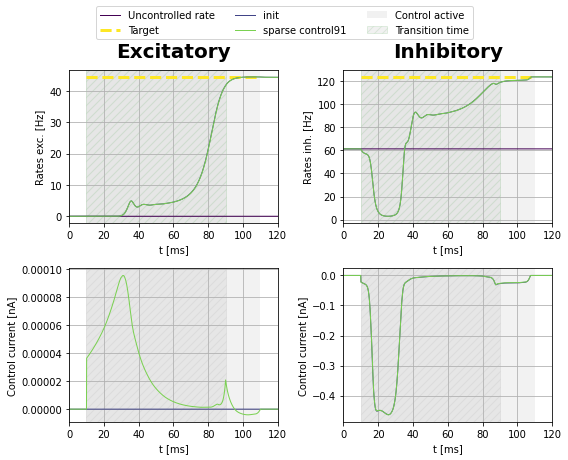

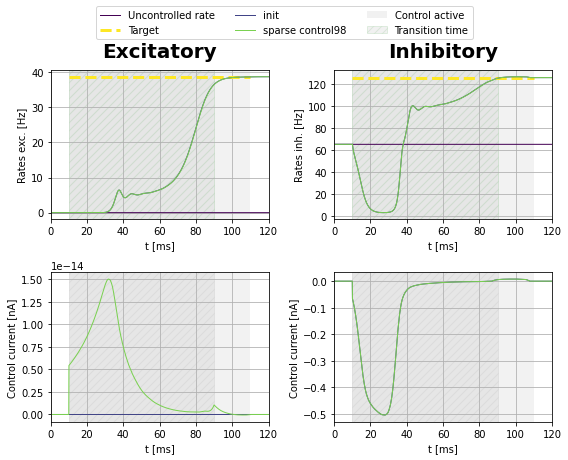

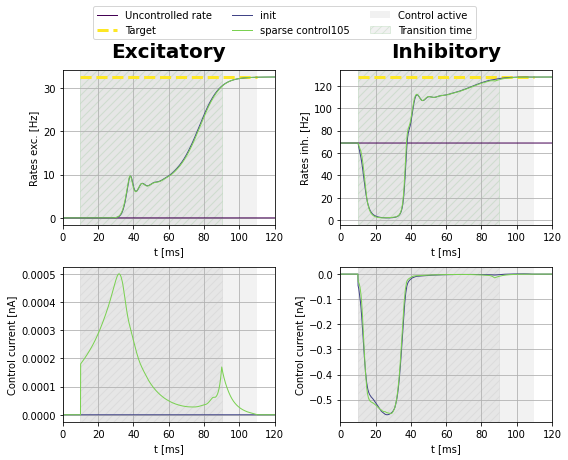

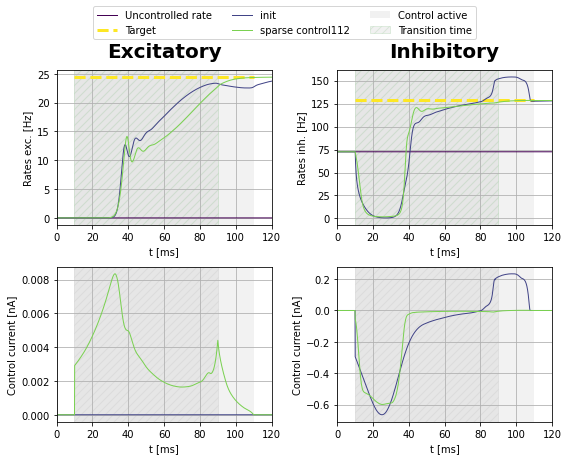

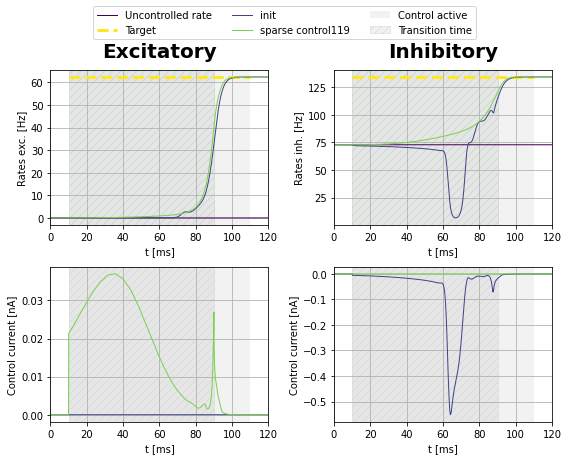

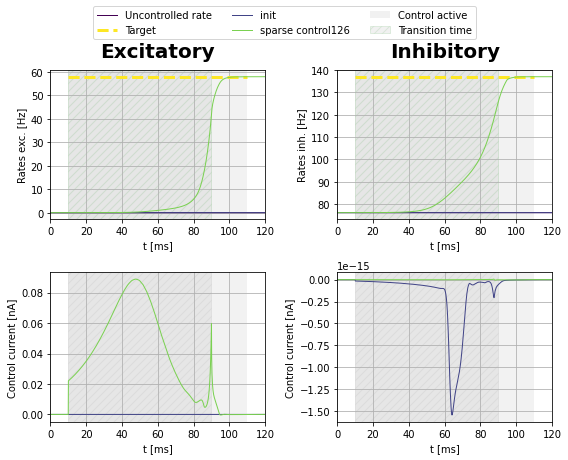

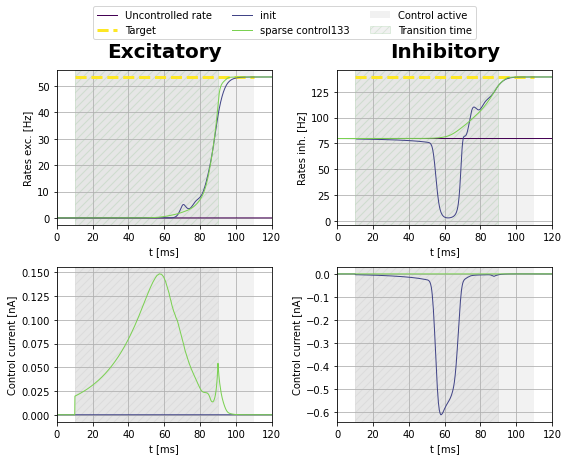

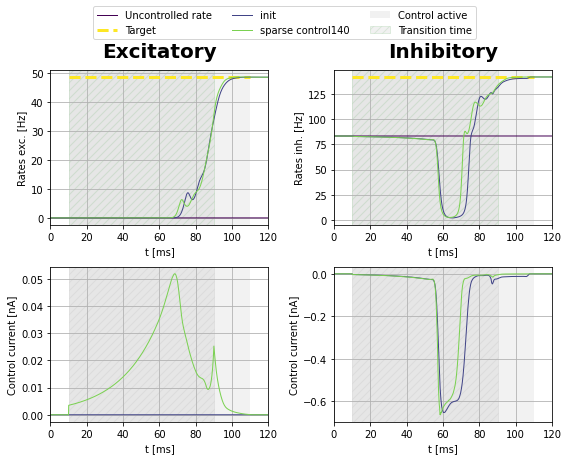

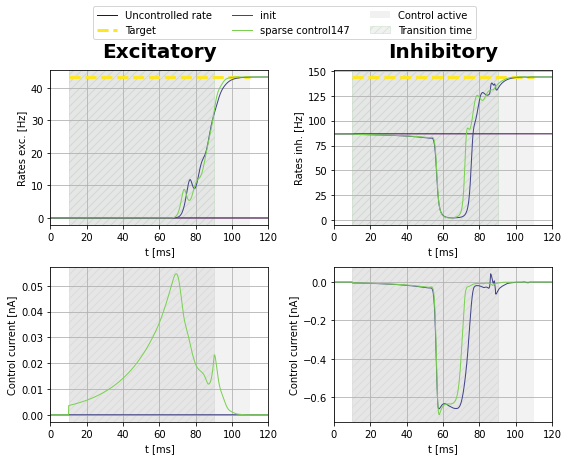

In [21]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [22]:
factor_iteration = 20
full_converge = False

while full_converge ==  False:
    
    if all(conv == True for conv in conv_0[::i_stepsize][0]):
        if all(conv == True for conv in conv_0[::i_stepsize][1]):
            full_converge = True
            break

    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
    

-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5661.920118645939
set cost params:  1.0 0.0 5661.920118645939
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5885.5166716997355
Gradient descend method:  None
RUN  1 , total integrated cost =  5885.342061130001
RUN  2 , total integrated cost =  5885.331490722422
RUN  3 , total integrated cost =  5885.330082332528
RUN  4 , total integrated cost =  5885.329834754565
RUN  5 , total integrated cost =  5885.329785675273
RUN  6 , total integrated cost =  5885.329773761776
RUN  7 , total integrated cost =  5885.329770846478
RUN  8 , total integrated cost =  5885.32977011847
RUN  9 , total integrated cost =  5885.3297699345385
RUN  10 , total integrated cost =  5885.329769886809
RUN  11 , total integrated cost =  5885.329769873912
RUN  12 , total integrated cost =  5885.329769870789
RUN  13 , total integrated cost =  5885.329769870062
RUN  14 , total integrated cost =  5885.329769869902
RUN  15 ,

ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  5885.329769869855
RUN  19 , total integrated cost =  5885.329769869855
Control only changes marginally.
RUN  19 , total integrated cost =  5885.329769869855
Improved over  19  iterations in  2.3141601644456387  seconds by  0.0031756231492607867  percent.
Problem in initial value trasfer:  Vmean_exc -56.626009236991976 -56.626010812894656
-------  7 0.4000000000000001 0.3750000000000001
no convergence
weight =  3147.5618730992546
set cost params:  1.0 0.0 3147.5618730992546
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5526.177450798157
Gradient descend method:  None
RUN  1 , total integrated cost =  5525.944372709978
RUN  2 , total integrated cost =  5525.935209834581
RUN  3 , total integrated cost =  5525.934041681905
RUN  4 , total integrated cost =  5525.933873514091
RUN  5 , total integrated cost =  5525.9338469948825
RUN  6 , total integrated cost =  5525.933845205487
RUN  7 , total integrated cost =  5525.933844949287
R

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  5525.933844901361
Control only changes marginally.
RUN  15 , total integrated cost =  5525.933844901361
Improved over  15  iterations in  1.6398764960467815  seconds by  0.004408217053565977  percent.
Problem in initial value trasfer:  Vmean_exc -56.62576967932038 -56.625753456563345
-------  14 0.4000000000000001 0.42500000000000016
no convergence
weight =  1386.8446995961256
set cost params:  1.0 0.0 1386.8446995961256
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4638.437810483489
Gradient descend method:  None


...

RUN  1 , total integrated cost =  5901.367092292144
Control only changes marginally.
RUN  1 , total integrated cost =  5901.367092292144
Improved over  1  iterations in  0.2000505719333887  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.626008884338454 -56.626010457526235
-------  7 0.4000000000000001 0.3750000000000001
no convergence
weight =  3154.042014496655
set cost params:  1.0 0.0 3154.042014496655
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5536.952241338459
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5536.952241338458
RUN  2 , total integrated cost =  5536.952241338458
Control only changes marginally.
RUN  2 , total integrated cost =  5536.952241338458
Improved over  2  iterations in  0.38829135335981846  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.62577288762468 -56.62575663622039
-------  14 0.4000000000000001 0.42500000000000016
converged for  14
-------  21 0.47500000000000014 0.4500000000000002
converged for  21
-------  28 0.5250000000000001 0.4750000000000002
converged for  28
-------  35 0.4250000000000001 0.5250000000000002
converged for  35
-------  42 0.4500000000000001 0.5500000000000003
converged for  42
-------  49 0.47500000000000014 0.5750000000000003
converged for  49
-------  56 0.5000000000000002 0.6000000000000003
converged for  56
-------  63 0.5000000000000002 0.6250000000000003
converged for  63
-------  70 0.5000000000000002 0.6500000000000004
converged for  70
-------  77 0.

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5536.952251843418
Control only changes marginally.
RUN  1 , total integrated cost =  5536.952251843418
Improved over  1  iterations in  0.21898557245731354  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62577288762468 -56.62575663622039
-------  14 0.4000000000000001 0.42500000000000016
converged for  14
-------  21 0.47500000000000014 0.4500000000000002
converged for  21
-------  28 0.5250000000000001 0.4750000000000002
converged for  28
-------  35 0.4250000000000001 0.5250000000000002
converged for  35
-------  42 0.4500000000000001 0.5500000000000003
converged for  42
-------  49 0.47500000000000014 0.5750000000000003
converged for  49
-------  56 0.5000000000000002 0.6000000000000003
converged for  56
-------  63 0.5000000000000002 0.6250000000000003
converged for  63
-------  70 0.5000000000000002 0.6500000000000004
converged for  70
-------  77 0.5000000000000002 0.6750000000000004
converged for  77
-------  84 0.500

In [23]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
